Cell 1 — Import libraries + paths.py

In [1]:
# ============================================================
# CELL 1: Import libraries + load paths.py
# ============================================================

from pathlib import Path
import sys
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

warnings.filterwarnings("ignore")

plt.rcParams["font.family"] = "serif"
plt.rcParams["figure.dpi"] = 120

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

# =====================================================
# Import project paths
# =====================================================
# Nếu notebook nằm trong /notebooks, thêm PROJECT_ROOT vào sys.path
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.path import (
    DATA_PREPROCESSED_FILE, 
    MODELS_DIR, 
    REPORTS_DIR, 
    FIGURES_DIR,
    check_and_create_directories
)

# ------------------------------------------------------------
# Output folders for base_tree.ipynb
# ------------------------------------------------------------

BASE_TREE_TABLE_DIR = REPORTS_DIR / "modeling" / "base_tree"
BASE_TREE_FIGURE_DIR = FIGURES_DIR / "modeling" / "base_tree"
BASE_TREE_MODEL_DIR = MODELS_DIR / "base_tree"

BASE_TREE_TABLE_DIR.mkdir(parents=True, exist_ok=True)
BASE_TREE_FIGURE_DIR.mkdir(parents=True, exist_ok=True)
BASE_TREE_MODEL_DIR.mkdir(parents=True, exist_ok=True)


print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_PREPROCESSED_FILE:", DATA_PREPROCESSED_FILE)
print("BASE_TREE_TABLE_DIR:", BASE_TREE_TABLE_DIR)
print("BASE_TREE_FIGURE_DIR:", BASE_TREE_FIGURE_DIR)
print("BASE_TREE_MODEL_DIR:", BASE_TREE_MODEL_DIR)

PROJECT_ROOT: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn
DATA_PREPROCESSED_FILE: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\data\preprocessed_data\preprocessed_data.csv
BASE_TREE_TABLE_DIR: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\modeling\base_tree
BASE_TREE_FIGURE_DIR: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\figures\modeling\base_tree
BASE_TREE_MODEL_DIR: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\models\base_tree


Cell 2 — Optional imports cho XGBoost / LightGBM / CatBoost

In [2]:
# ============================================================
# CELL 2: Optional imports for boosting models
# ============================================================

HAS_XGBOOST = False
HAS_LIGHTGBM = False
HAS_CATBOOST = False

try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
    print("XGBoost available.")
except ImportError:
    print("XGBoost is not installed. XGBoost will be skipped.")

try:
    from lightgbm import LGBMClassifier
    HAS_LIGHTGBM = True
    print("LightGBM available.")
except ImportError:
    print("LightGBM is not installed. LightGBM will be skipped.")

try:
    from catboost import CatBoostClassifier
    HAS_CATBOOST = True
    print("CatBoost available.")
except ImportError:
    print("CatBoost is not installed. CatBoost will be skipped.")

XGBoost available.
LightGBM available.
CatBoost available.


Cell 3 — Load dataset

In [3]:
# ============================================================
# CELL 3: Load cleaned input dataset
# ============================================================

df = pd.read_csv(DATA_PREPROCESSED_FILE)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes.to_string())

print("\nMissing values:")
print(df.isna().sum().to_string())

print("\nFirst 5 rows:")
print(df.head().to_string(index=False))

Dataset loaded successfully.
Shape: (7043, 16)

Columns:
['ID', 'Churn', 'SeniorCitizen', 'Partner', 'Dependents', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'Tenure', 'Contract', 'PaymentMethod', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges']

Data types:
ID                   object
Churn                 int64
SeniorCitizen         int64
Partner               int64
Dependents           object
InternetService      object
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
Tenure                int64
Contract              int64
PaymentMethod        object
PaperlessBilling      int64
MonthlyCharges      float64
TotalCharges        float64

Missing values:
ID                  0
Churn               0
SeniorCitizen       0
Partner             0
Dependents          0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
Tenure

Cell 5 — Define X/y + Train/Test split

In [4]:
# ============================================================
# CELL 5: Define X/y and train-test split
# ============================================================

RANDOM_STATE = 42
TEST_SIZE = 0.20

customer_id = df["ID"].copy()

X = df.drop(columns=["ID", "Churn"])
y = df["Churn"].astype(int)

X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X,
    y,
    customer_id,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Train/Test split completed.")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True).to_string())

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).to_string())

Train/Test split completed.
X_train shape: (5634, 14)
X_test shape: (1409, 14)

Train target distribution:
Churn
0    0.734647
1    0.265353

Test target distribution:
Churn
0    0.734564
1    0.265436


In [5]:
# ============================================================
# CELL 6: Feature engineering after train-test split
# ============================================================

def create_tree_features_after_split(X_train_input, X_test_input):
    """
    Feature engineering for tree-based models.

    Important:
    - Fit train-dependent statistics on X_train only.
    - monthly_charges_ratio uses train MonthlyCharges mean only.
    - No capping.
    - No scaling.
    - No log transform.
    """

    X_train_fe = X_train_input.copy()
    X_test_fe = X_test_input.copy()

    # --------------------------------------------------------
    # Contract_Label
    # --------------------------------------------------------

    contract_mapping = {
        1: "Month-to-month",
        12: "One year",
        24: "Two year",
    }

    X_train_fe["Contract_Label"] = X_train_fe["Contract"].map(contract_mapping).fillna("Unknown")
    X_test_fe["Contract_Label"] = X_test_fe["Contract"].map(contract_mapping).fillna("Unknown")

    # Drop original Contract to avoid duplicate information
    X_train_fe = X_train_fe.drop(columns=["Contract"])
    X_test_fe = X_test_fe.drop(columns=["Contract"])

    # --------------------------------------------------------
    # tenure_group
    # --------------------------------------------------------

    tenure_bins = [-0.001, 12, 24, 36, 48, 60, 72, np.inf]
    tenure_labels = [
        "0-12 months",
        "13-24 months",
        "25-36 months",
        "37-48 months",
        "49-60 months",
        "61-72 months",
        "72+ months",
    ]

    X_train_fe["tenure_group"] = pd.cut(
        X_train_fe["Tenure"],
        bins=tenure_bins,
        labels=tenure_labels,
        include_lowest=True,
    ).astype(str)

    X_test_fe["tenure_group"] = pd.cut(
        X_test_fe["Tenure"],
        bins=tenure_bins,
        labels=tenure_labels,
        include_lowest=True,
    ).astype(str)

    # --------------------------------------------------------
    # service_diversity
    # --------------------------------------------------------

    service_columns = [
        "OnlineSecurity",
        "OnlineBackup",
        "DeviceProtection",
        "TechSupport",
    ]

    available_service_columns = [
        col for col in service_columns
        if col in X_train_fe.columns
    ]

    X_train_fe["service_diversity"] = (
        X_train_fe[available_service_columns]
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0)
        .sum(axis=1)
    )

    X_test_fe["service_diversity"] = (
        X_test_fe[available_service_columns]
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0)
        .sum(axis=1)
    )

    # --------------------------------------------------------
    # monthly_charges_ratio
    # --------------------------------------------------------

    train_monthly_charges_mean = X_train_fe["MonthlyCharges"].mean()

    X_train_fe["monthly_charges_ratio"] = (
        X_train_fe["MonthlyCharges"] / train_monthly_charges_mean
    )

    X_test_fe["monthly_charges_ratio"] = (
        X_test_fe["MonthlyCharges"] / train_monthly_charges_mean
    )

    # --------------------------------------------------------
    # is_paperless_electronic
    # --------------------------------------------------------

    X_train_fe["is_paperless_electronic"] = (
        (X_train_fe["PaperlessBilling"] == 1)
        & (
            X_train_fe["PaymentMethod"]
            .astype(str)
            .str.contains("Electronic", case=False, na=False)
        )
    ).astype(int)

    X_test_fe["is_paperless_electronic"] = (
        (X_test_fe["PaperlessBilling"] == 1)
        & (
            X_test_fe["PaymentMethod"]
            .astype(str)
            .str.contains("Electronic", case=False, na=False)
        )
    ).astype(int)

    return X_train_fe, X_test_fe, train_monthly_charges_mean


X_train_tree, X_test_tree, train_monthly_charges_mean = create_tree_features_after_split(
    X_train,
    X_test,
)

print("Feature engineering completed.")
print("Train MonthlyCharges mean used:", train_monthly_charges_mean)

print("\nX_train_tree shape:", X_train_tree.shape)
print("X_test_tree shape:", X_test_tree.shape)

print("\nX_train_tree columns:")
print(X_train_tree.columns.tolist())

print("\nFirst 5 rows after feature engineering:")
print(X_train_tree.head().to_string(index=False))

Feature engineering completed.
Train MonthlyCharges mean used: 64.92996095136671

X_train_tree shape: (5634, 18)
X_test_tree shape: (1409, 18)

X_train_tree columns:
['SeniorCitizen', 'Partner', 'Dependents', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'Tenure', 'PaymentMethod', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Contract_Label', 'tenure_group', 'service_diversity', 'monthly_charges_ratio', 'is_paperless_electronic']

First 5 rows after feature engineering:
 SeniorCitizen  Partner Dependents InternetService  OnlineSecurity  OnlineBackup  DeviceProtection  TechSupport  Tenure           PaymentMethod  PaperlessBilling  MonthlyCharges  TotalCharges Contract_Label tenure_group  service_diversity  monthly_charges_ratio  is_paperless_electronic
             0        0         No             DSL               0             0                 1            0      35        Electronic check                 0           49.20       170

In [6]:
# ============================================================
# CELL 7: Define feature lists for tree-based models
# ============================================================

binary_numeric_features = [
    "SeniorCitizen",
    "Partner",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "PaperlessBilling",
]

continuous_numeric_features = [
    "Tenure",
    "MonthlyCharges",
    "TotalCharges",
    "service_diversity",
    "monthly_charges_ratio",
    "is_paperless_electronic",
]

categorical_features = [
    "Dependents",
    "InternetService",
    "PaymentMethod",
    "Contract_Label",
    "tenure_group",
]

numeric_features = binary_numeric_features + continuous_numeric_features

# Keep only available columns
numeric_features = [
    col for col in numeric_features
    if col in X_train_tree.columns
]

categorical_features = [
    col for col in categorical_features
    if col in X_train_tree.columns
]

selected_features = numeric_features + categorical_features

X_train_model = X_train_tree[selected_features].copy()
X_test_model = X_test_tree[selected_features].copy()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("\nSelected features:")
print(selected_features)

print("\nX_train_model shape:", X_train_model.shape)
print("X_test_model shape:", X_test_model.shape)

print("\nSample X_train_model:")
print(X_train_model.head().to_string(index=False))

Numeric features:
['SeniorCitizen', 'Partner', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'PaperlessBilling', 'Tenure', 'MonthlyCharges', 'TotalCharges', 'service_diversity', 'monthly_charges_ratio', 'is_paperless_electronic']

Categorical features:
['Dependents', 'InternetService', 'PaymentMethod', 'Contract_Label', 'tenure_group']

Selected features:
['SeniorCitizen', 'Partner', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'PaperlessBilling', 'Tenure', 'MonthlyCharges', 'TotalCharges', 'service_diversity', 'monthly_charges_ratio', 'is_paperless_electronic', 'Dependents', 'InternetService', 'PaymentMethod', 'Contract_Label', 'tenure_group']

X_train_model shape: (5634, 18)
X_test_model shape: (1409, 18)

Sample X_train_model:
 SeniorCitizen  Partner  OnlineSecurity  OnlineBackup  DeviceProtection  TechSupport  PaperlessBilling  Tenure  MonthlyCharges  TotalCharges  service_diversity  monthly_charges_ratio  is_paperless_electronic Depen

Cell 8 — Shared tree preprocessing

In [7]:
# ============================================================
# CELL 8: Shared tree-based preprocessing
# ============================================================

tree_numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

tree_categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "ordinal",
            OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1,
            )
        ),
    ]
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", tree_categorical_transformer, categorical_features),
        ("numeric", tree_numeric_transformer, numeric_features),
    ],
    remainder="drop",
)

X_train_processed = tree_preprocessor.fit_transform(X_train_model)
X_test_processed = tree_preprocessor.transform(X_test_model)

# ColumnTransformer order is categorical first, then numeric
tree_feature_names = categorical_features + numeric_features

X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=tree_feature_names,
    index=X_train_model.index,
)

X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=tree_feature_names,
    index=X_test_model.index,
)

print("Shared tree preprocessing completed.")
print("X_train_processed_df shape:", X_train_processed_df.shape)
print("X_test_processed_df shape:", X_test_processed_df.shape)

print("\nProcessed feature names:")
print(tree_feature_names)

print("\nFirst 5 processed rows:")
print(X_train_processed_df.head().to_string(index=False))


# Save shared preprocessor
tree_preprocessor_path = BASE_TREE_MODEL_DIR / "tree_shared_preprocessor.joblib"
joblib.dump(tree_preprocessor, tree_preprocessor_path)

print("\nSaved tree preprocessor:")
print(tree_preprocessor_path)

Shared tree preprocessing completed.
X_train_processed_df shape: (5634, 18)
X_test_processed_df shape: (1409, 18)

Processed feature names:
['Dependents', 'InternetService', 'PaymentMethod', 'Contract_Label', 'tenure_group', 'SeniorCitizen', 'Partner', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'PaperlessBilling', 'Tenure', 'MonthlyCharges', 'TotalCharges', 'service_diversity', 'monthly_charges_ratio', 'is_paperless_electronic']

First 5 processed rows:
 Dependents  InternetService  PaymentMethod  Contract_Label  tenure_group  SeniorCitizen  Partner  OnlineSecurity  OnlineBackup  DeviceProtection  TechSupport  PaperlessBilling  Tenure  MonthlyCharges  TotalCharges  service_diversity  monthly_charges_ratio  is_paperless_electronic
        0.0              0.0            2.0             0.0           2.0            0.0      0.0             0.0           0.0               1.0          0.0               0.0    35.0           49.20       1701.65                1.0 

In [8]:
# ============================================================
# CELL 9: Class imbalance values
# ============================================================

num_non_churn = int((y_train == 0).sum())
num_churn = int((y_train == 1).sum())

scale_pos_weight = num_non_churn / num_churn

print("Class distribution in training set:")
print("Non-Churn:", num_non_churn)
print("Churn:", num_churn)
print("scale_pos_weight:", scale_pos_weight)

Class distribution in training set:
Non-Churn: 4139
Churn: 1495
scale_pos_weight: 2.768561872909699


In [9]:
# ============================================================
# CELL 10: Define tree-based models
# ============================================================

tree_models = {}

# ------------------------------------------------------------
# Random Forest
# ------------------------------------------------------------

tree_models["Random Forest"] = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

# ------------------------------------------------------------
# XGBoost
# ------------------------------------------------------------

if HAS_XGBOOST:
    tree_models["XGBoost"] = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        scale_pos_weight=scale_pos_weight,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

# ------------------------------------------------------------
# LightGBM
# ------------------------------------------------------------

if HAS_LIGHTGBM:
    tree_models["LightGBM"] = LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        subsample=0.9,
        colsample_bytree=0.9,
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    )

# ------------------------------------------------------------
# CatBoost
# ------------------------------------------------------------

if HAS_CATBOOST:
    tree_models["CatBoost"] = CatBoostClassifier(
        iterations=300,
        depth=4,
        learning_rate=0.05,
        loss_function="Logloss",
        eval_metric="AUC",
        class_weights=[1, scale_pos_weight],
        random_seed=RANDOM_STATE,
        verbose=False,
    )


print("Models to train:")
for model_name in tree_models.keys():
    print("-", model_name)

if len(tree_models) == 0:
    raise RuntimeError("No tree-based models available for training.")

Models to train:
- Random Forest
- XGBoost
- LightGBM
- CatBoost


In [10]:
# ============================================================
# CELL 11: Train and evaluate all tree-based models
# ============================================================

DEFAULT_THRESHOLD = 0.50

tree_metrics_rows = []
tree_predictions = {}
tree_probabilities = {}
trained_tree_models = {}

for model_name, model in tree_models.items():
    print("\n" + "=" * 80)
    print(f"Training model: {model_name}")
    print("=" * 80)

    model.fit(X_train_processed_df, y_train)

    y_proba = model.predict_proba(X_test_processed_df)[:, 1]
    y_pred = (y_proba >= DEFAULT_THRESHOLD).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    metrics_row = {
        "Model": model_name,
        "Threshold": DEFAULT_THRESHOLD,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
    }

    tree_metrics_rows.append(metrics_row)

    tree_predictions[model_name] = y_pred
    tree_probabilities[model_name] = y_proba
    trained_tree_models[model_name] = model

    print("Metrics:")
    print(pd.DataFrame([metrics_row]).to_string(index=False))

    print("\nClassification report:")
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["Non-Churn", "Churn"],
            zero_division=0,
        )
    )

    safe_name = model_name.lower().replace(" ", "_").replace("-", "_")

    model_path = BASE_TREE_MODEL_DIR / f"{safe_name}_model.joblib"
    joblib.dump(model, model_path)

    print("Saved model:")
    print(model_path)


tree_metrics_df = pd.DataFrame(tree_metrics_rows)

tree_metrics_path = BASE_TREE_TABLE_DIR / "tree_model_comparison_metrics.csv"
tree_metrics_df.to_csv(tree_metrics_path, index=False)

print("\n" + "=" * 80)
print("Saved:", tree_metrics_path)
print("\ntree_model_comparison_metrics.csv:")
print(tree_metrics_df.to_string(index=False))


Training model: Random Forest
Metrics:
        Model  Threshold  Accuracy  Precision   Recall  F1-score  ROC-AUC  TN  FP  FN  TP
Random Forest        0.5  0.787083    0.62585 0.491979  0.550898 0.831429 925 110 190 184

Classification report:
              precision    recall  f1-score   support

   Non-Churn       0.83      0.89      0.86      1035
       Churn       0.63      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409

Saved model:
D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\models\base_tree\random_forest_model.joblib

Training model: XGBoost
Metrics:
  Model  Threshold  Accuracy  Precision   Recall  F1-score  ROC-AUC  TN  FP  FN  TP
XGBoost        0.5  0.752307   0.522686 0.770053  0.622703 0.850586 772 263  86 288

Classification report:
              precision    recall  f1-score   support

   Non-Churn       0.90      0.75      0.82  

In [12]:
# ============================================================
# CELL 12: Export test predictions
# ============================================================

tree_predictions_output_df = pd.DataFrame({
    "ID": id_test.values,
    "actual_churn": y_test.values,
})

for model_name in trained_tree_models.keys():
    safe_name = model_name.lower().replace(" ", "_").replace("-", "_")

    tree_predictions_output_df[f"{safe_name}_predicted_churn"] = tree_predictions[model_name]
    tree_predictions_output_df[f"{safe_name}_churn_probability"] = tree_probabilities[model_name]

tree_predictions_output_path = BASE_TREE_TABLE_DIR / "tree_model_test_predictions.csv"
tree_predictions_output_df.to_csv(tree_predictions_output_path, index=False)

print("Saved:", tree_predictions_output_path)

Saved: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\modeling\base_tree\tree_model_test_predictions.csv


In [13]:
# ============================================================
# CELL 13: Threshold Sensitivity Analysis
# ============================================================

thresholds = [0.50, 0.45, 0.40, 0.35, 0.30]

tree_threshold_rows = []

for model_name in trained_tree_models.keys():
    y_proba = tree_probabilities[model_name]

    for threshold in thresholds:
        y_pred_threshold = (y_proba >= threshold).astype(int)

        tree_threshold_rows.append({
            "Model": model_name,
            "Threshold": threshold,
            "Accuracy": accuracy_score(y_test, y_pred_threshold),
            "Precision": precision_score(y_test, y_pred_threshold, zero_division=0),
            "Recall": recall_score(y_test, y_pred_threshold, zero_division=0),
            "F1-score": f1_score(y_test, y_pred_threshold, zero_division=0),
            "ROC-AUC": roc_auc_score(y_test, y_proba),
        })

tree_threshold_sensitivity_df = pd.DataFrame(tree_threshold_rows)

tree_threshold_sensitivity_path = BASE_TREE_TABLE_DIR / "tree_threshold_sensitivity.csv"
tree_threshold_sensitivity_df.to_csv(tree_threshold_sensitivity_path, index=False)

print("Saved:", tree_threshold_sensitivity_path)
print("\ntree_threshold_sensitivity.csv:")
print(tree_threshold_sensitivity_df.to_string(index=False))

Saved: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\modeling\base_tree\tree_threshold_sensitivity.csv

tree_threshold_sensitivity.csv:
        Model  Threshold  Accuracy  Precision   Recall  F1-score  ROC-AUC
Random Forest       0.50  0.787083   0.625850 0.491979  0.550898 0.831429
Random Forest       0.45  0.792051   0.618768 0.564171  0.590210 0.831429
Random Forest       0.40  0.782825   0.587629 0.609626  0.598425 0.831429
Random Forest       0.35  0.772179   0.558758 0.673797  0.610909 0.831429
Random Forest       0.30  0.760114   0.535714 0.721925  0.615034 0.831429
      XGBoost       0.50  0.752307   0.522686 0.770053  0.622703 0.850586
      XGBoost       0.45  0.741661   0.508446 0.804813  0.623188 0.850586
      XGBoost       0.40  0.728176   0.492936 0.839572  0.621167 0.850586
      XGBoost       0.35  0.708304   0.473227 0.874332  0.614085 0.850586
      XGBoost       0.30  0.685593   0.452933 0.887701  0.599819 0.850586
     LightGBM       0.50  0.757984   0.531

In [14]:
# ============================================================
# CELL 14: Export feature importance tables
# ============================================================

feature_importance_dfs = {}

for model_name, model in trained_tree_models.items():
    print("\n" + "=" * 80)
    print(f"Feature importance: {model_name}")
    print("=" * 80)

    if not hasattr(model, "feature_importances_"):
        print(f"{model_name} does not support feature_importances_. Skipped.")
        continue

    importance_df = pd.DataFrame({
        "feature": tree_feature_names,
        "importance": model.feature_importances_,
    })

    importance_df = importance_df.sort_values(
        by="importance",
        ascending=False,
    )

    feature_importance_dfs[model_name] = importance_df

    safe_name = model_name.lower().replace(" ", "_").replace("-", "_")

    importance_path = BASE_TREE_TABLE_DIR / f"{safe_name}_feature_importance.csv"
    importance_df.to_csv(importance_path, index=False)

    print("Saved:", importance_path)
    print(f"\n{safe_name}_feature_importance.csv - top 30 rows:")
    print(importance_df.head(30).to_string(index=False))


Feature importance: Random Forest
Saved: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\modeling\base_tree\random_forest_feature_importance.csv

random_forest_feature_importance.csv - top 30 rows:
                feature  importance
         MonthlyCharges    0.138902
           TotalCharges    0.138166
  monthly_charges_ratio    0.135415
                 Tenure    0.127527
         Contract_Label    0.110198
             Dependents    0.052351
           tenure_group    0.050643
is_paperless_electronic    0.034822
          PaymentMethod    0.034414
        InternetService    0.033544
      service_diversity    0.033259
                Partner    0.020250
       PaperlessBilling    0.018485
         OnlineSecurity    0.016510
          SeniorCitizen    0.015249
            TechSupport    0.014423
           OnlineBackup    0.013955
       DeviceProtection    0.011888

Feature importance: XGBoost
Saved: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\modeling\base_tree\xg

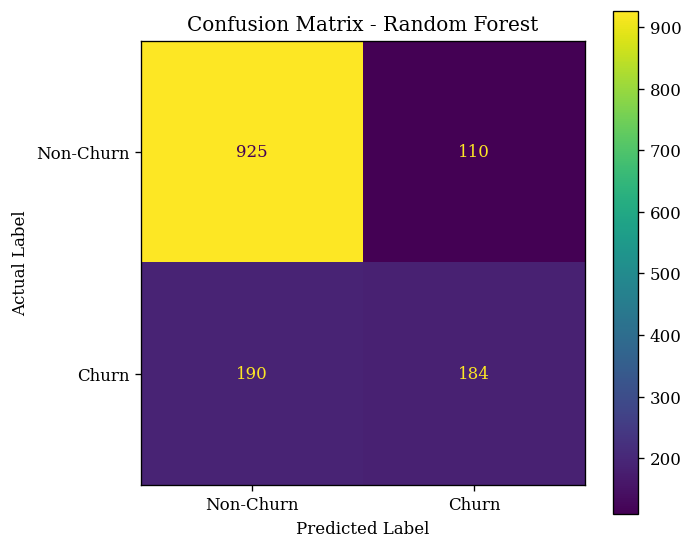

Saved: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\figures\modeling\base_tree\confusion_matrix_random_forest.png


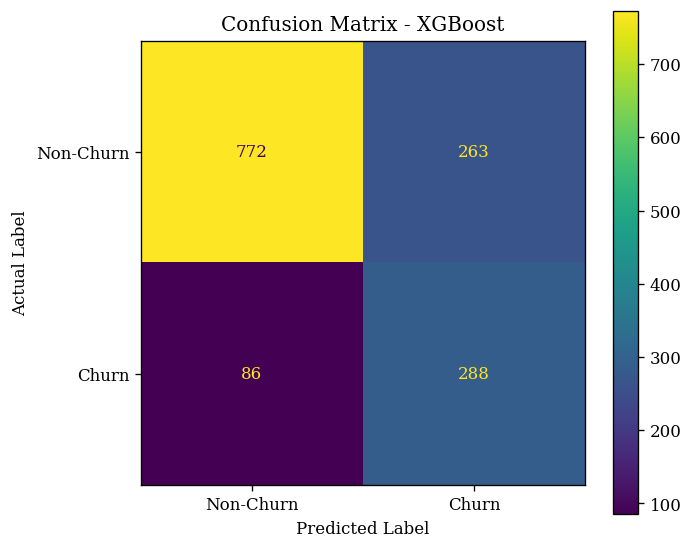

Saved: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\figures\modeling\base_tree\confusion_matrix_xgboost.png


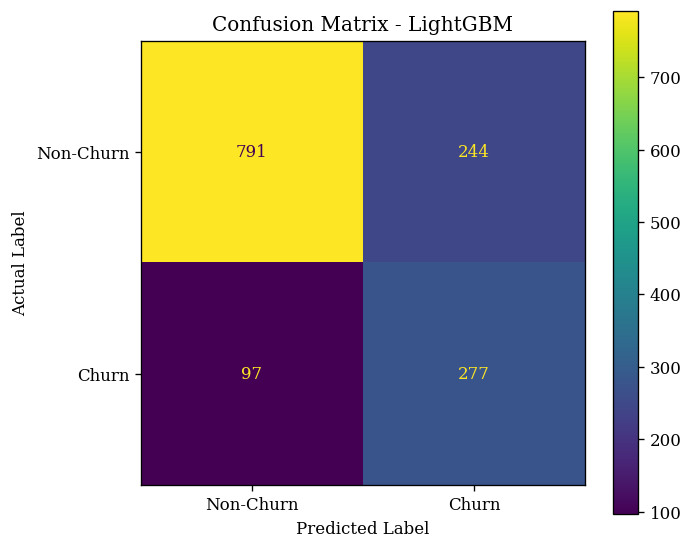

Saved: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\figures\modeling\base_tree\confusion_matrix_lightgbm.png


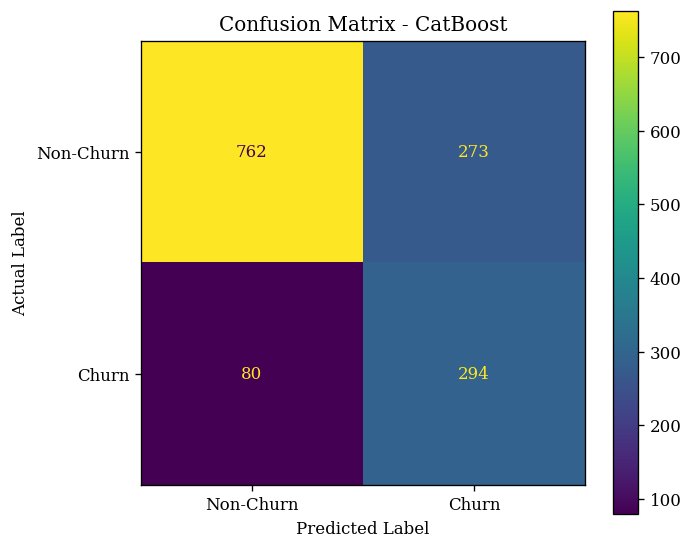

Saved: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\figures\modeling\base_tree\confusion_matrix_catboost.png


In [15]:
# ============================================================
# CELL 15: Confusion Matrix figures
# ============================================================

confusion_matrix_paths = {}

for model_name in trained_tree_models.keys():
    y_pred = tree_predictions[model_name]
    safe_name = model_name.lower().replace(" ", "_").replace("-", "_")

    fig, ax = plt.subplots(figsize=(6, 5))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=["Non-Churn", "Churn"],
        values_format="d",
        ax=ax,
    )

    ax.set_title(f"Confusion Matrix - {model_name}")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("Actual Label")

    confusion_matrix_path = BASE_TREE_FIGURE_DIR / f"confusion_matrix_{safe_name}.png"

    plt.tight_layout()
    plt.savefig(confusion_matrix_path, dpi=300, bbox_inches="tight")
    plt.show()

    confusion_matrix_paths[model_name] = confusion_matrix_path

    print("Saved:", confusion_matrix_path)

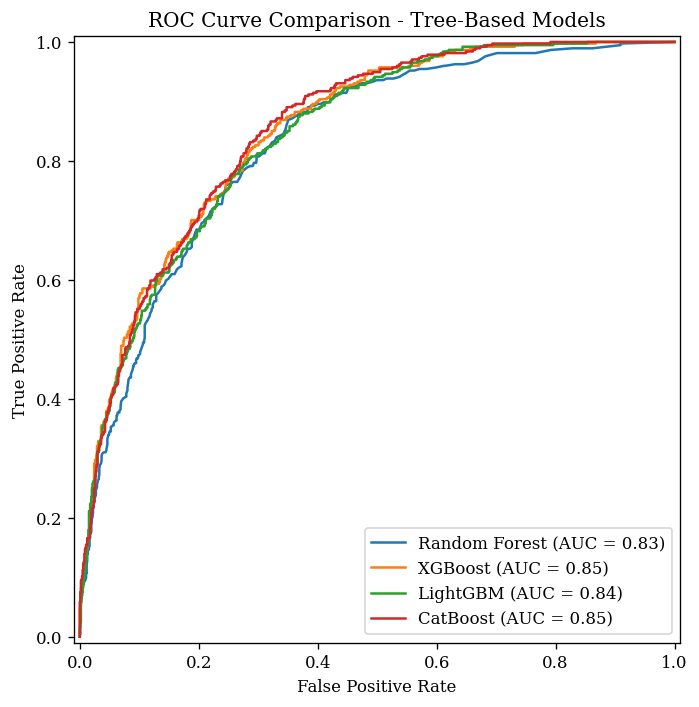

Saved: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\figures\modeling\base_tree\roc_curve_comparison_tree_models.png


In [16]:
# ============================================================
# CELL 16: ROC Curve comparison
# ============================================================

fig, ax = plt.subplots(figsize=(8, 6))

for model_name in trained_tree_models.keys():
    RocCurveDisplay.from_predictions(
        y_test,
        tree_probabilities[model_name],
        name=model_name,
        ax=ax,
    )

ax.set_title("ROC Curve Comparison - Tree-Based Models")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")

roc_tree_path = BASE_TREE_FIGURE_DIR / "roc_curve_comparison_tree_models.png"

plt.tight_layout()
plt.savefig(roc_tree_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", roc_tree_path)

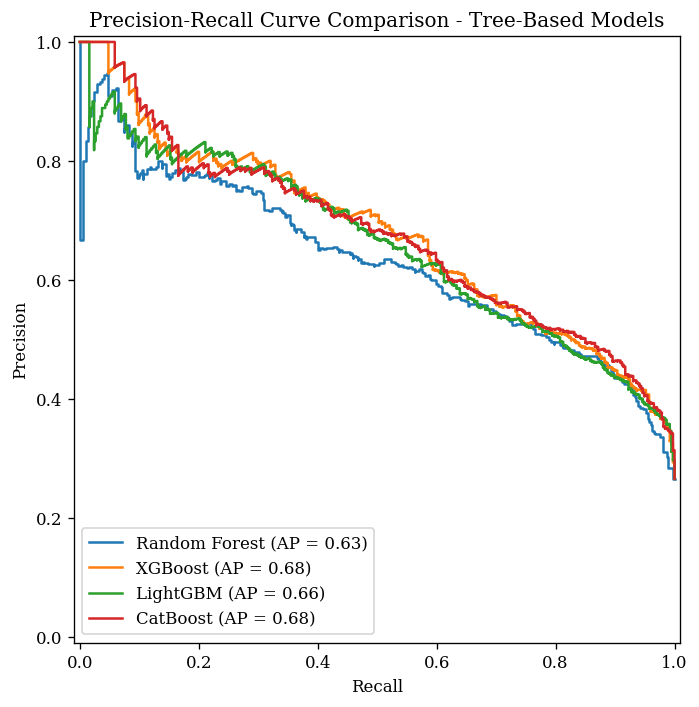

Saved: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\figures\modeling\base_tree\precision_recall_curve_comparison_tree_models.png


In [17]:
# ============================================================
# CELL 17: Precision-Recall Curve comparison
# ============================================================

fig, ax = plt.subplots(figsize=(8, 6))

for model_name in trained_tree_models.keys():
    PrecisionRecallDisplay.from_predictions(
        y_test,
        tree_probabilities[model_name],
        name=model_name,
        ax=ax,
    )

ax.set_title("Precision-Recall Curve Comparison - Tree-Based Models")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")

pr_tree_path = BASE_TREE_FIGURE_DIR / "precision_recall_curve_comparison_tree_models.png"

plt.tight_layout()
plt.savefig(pr_tree_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", pr_tree_path)

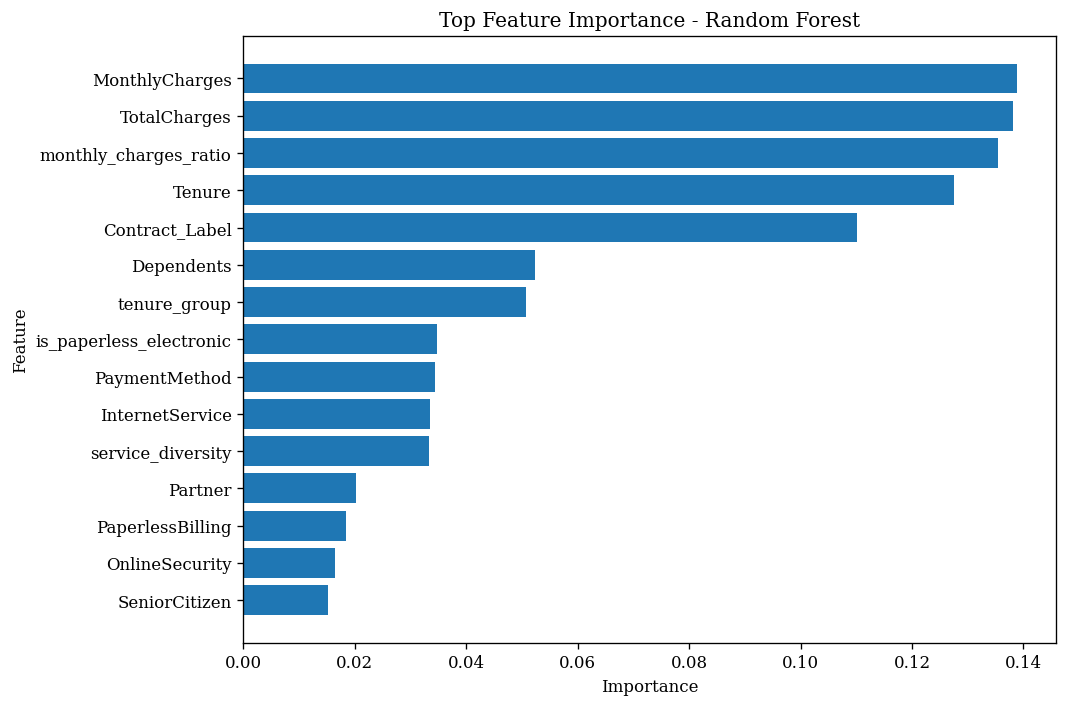

Saved: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\figures\modeling\base_tree\feature_importance_random_forest.png


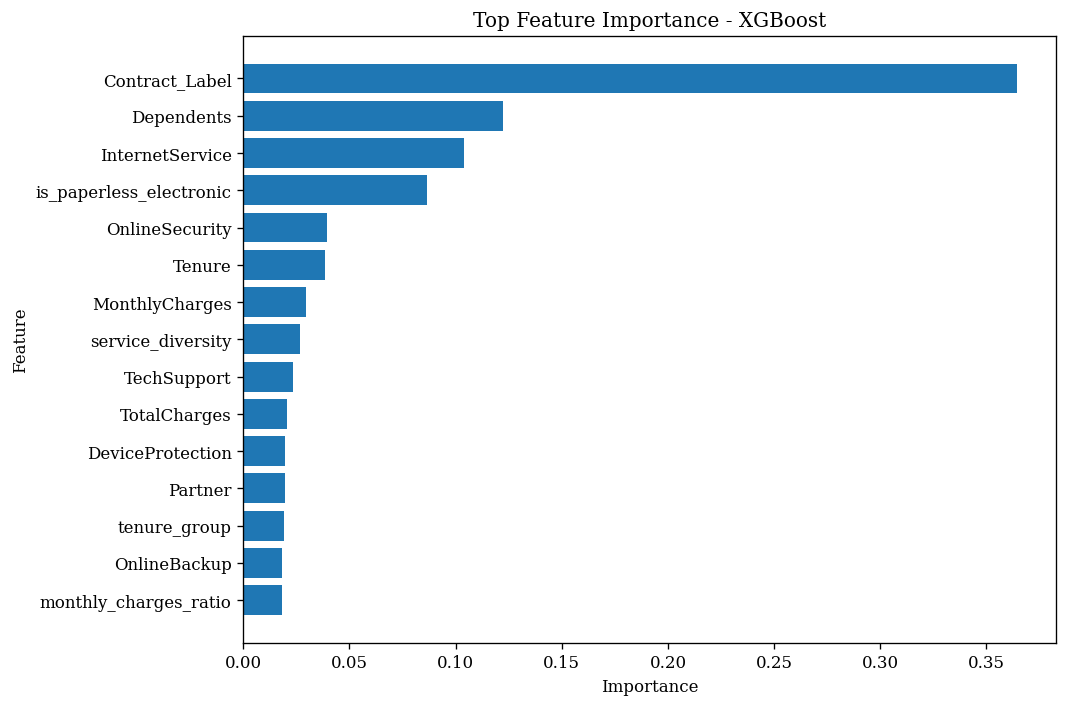

Saved: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\figures\modeling\base_tree\feature_importance_xgboost.png


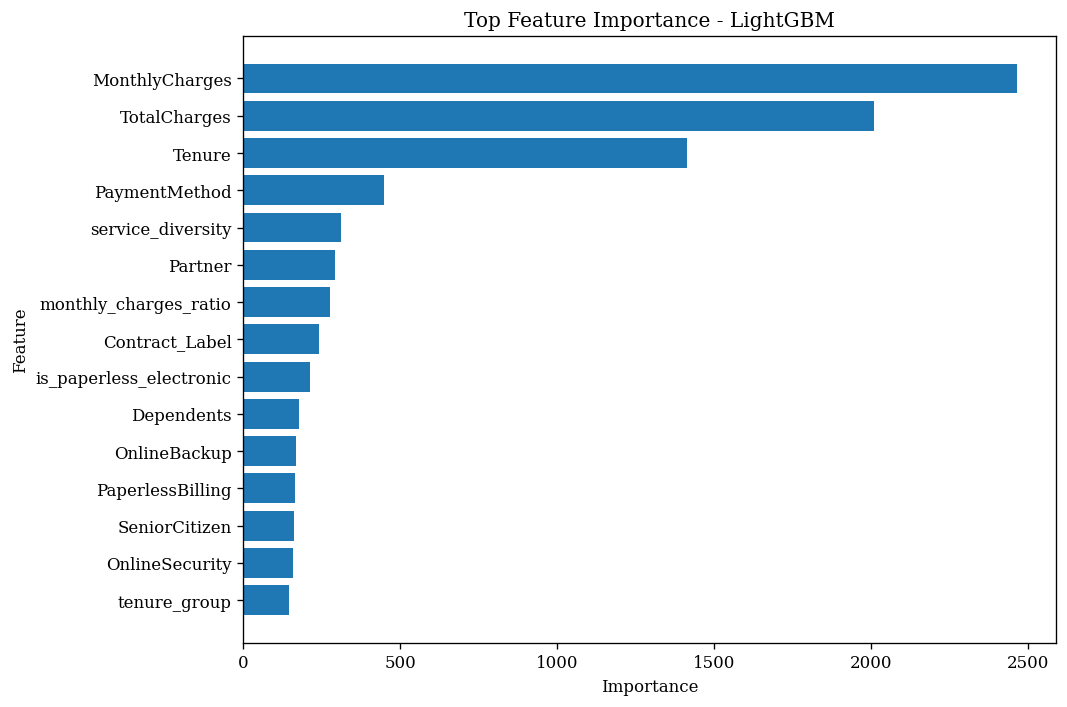

Saved: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\figures\modeling\base_tree\feature_importance_lightgbm.png


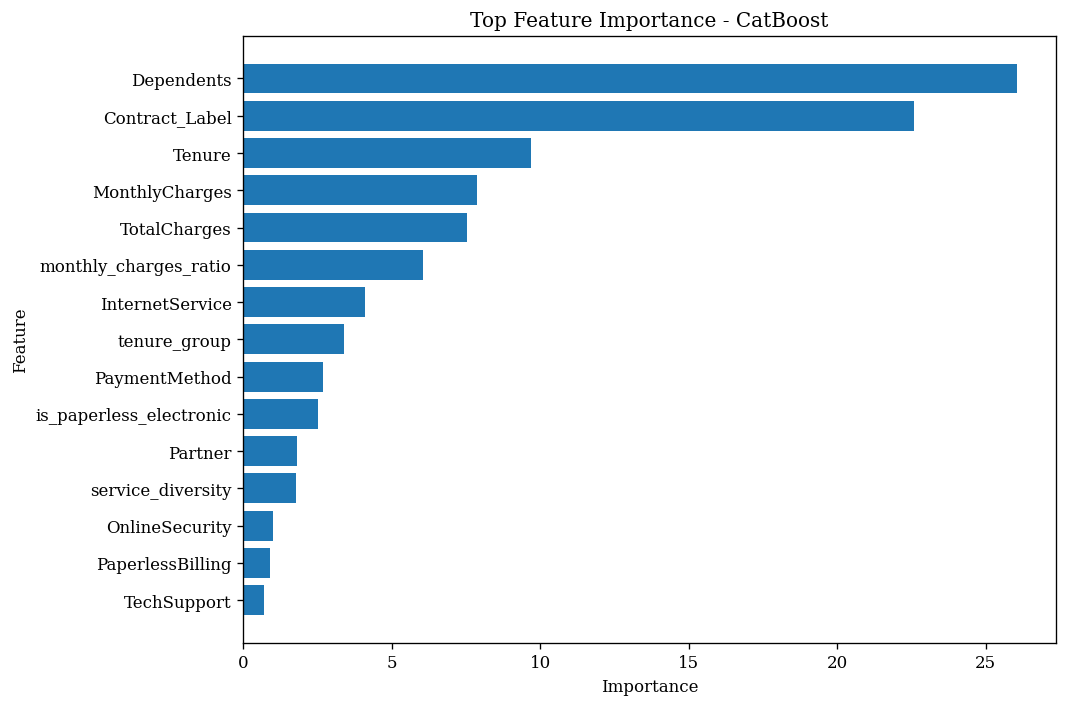

Saved: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\figures\modeling\base_tree\feature_importance_catboost.png


In [18]:
# ============================================================
# CELL 18: Feature importance figures
# ============================================================

feature_importance_figure_paths = {}

for model_name, importance_df in feature_importance_dfs.items():
    safe_name = model_name.lower().replace(" ", "_").replace("-", "_")

    top_features = (
        importance_df
        .head(15)
        .sort_values("importance", ascending=True)
    )

    fig, ax = plt.subplots(figsize=(9, 6))

    ax.barh(top_features["feature"], top_features["importance"])
    ax.set_title(f"Top Feature Importance - {model_name}")
    ax.set_xlabel("Importance")
    ax.set_ylabel("Feature")

    feature_importance_path = BASE_TREE_FIGURE_DIR / f"feature_importance_{safe_name}.png"

    plt.tight_layout()
    plt.savefig(feature_importance_path, dpi=300, bbox_inches="tight")
    plt.show()

    feature_importance_figure_paths[model_name] = feature_importance_path

    print("Saved:", feature_importance_path)

In [19]:
# ============================================================
# CELL 19: Final summary
# ============================================================

print("BASE TREE NOTEBOOK COMPLETED")
print("=" * 80)

print("\nCSV outputs:")
print(tree_metrics_path)
print(tree_predictions_output_path)
print(tree_threshold_sensitivity_path)

for model_name in feature_importance_dfs.keys():
    safe_name = model_name.lower().replace(" ", "_").replace("-", "_")
    print(BASE_TREE_TABLE_DIR / f"{safe_name}_feature_importance.csv")

print("\nFigure outputs:")
for path in confusion_matrix_paths.values():
    print(path)

print(roc_tree_path)
print(pr_tree_path)

for path in feature_importance_figure_paths.values():
    print(path)

print("\nModel outputs:")
print(tree_preprocessor_path)

for model_name in trained_tree_models.keys():
    safe_name = model_name.lower().replace(" ", "_").replace("-", "_")
    print(BASE_TREE_MODEL_DIR / f"{safe_name}_model.joblib")

print("\nModel comparison with 5 metrics:")
print(
    tree_metrics_df[
        [
            "Model",
            "Threshold",
            "Accuracy",
            "Precision",
            "Recall",
            "F1-score",
            "ROC-AUC",
        ]
    ].to_string(index=False)
)

print("\nThreshold sensitivity with 5 metrics:")
print(
    tree_threshold_sensitivity_df[
        [
            "Model",
            "Threshold",
            "Accuracy",
            "Precision",
            "Recall",
            "F1-score",
            "ROC-AUC",
        ]
    ].to_string(index=False)
)

BASE TREE NOTEBOOK COMPLETED

CSV outputs:
D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\modeling\base_tree\tree_model_comparison_metrics.csv
D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\modeling\base_tree\tree_model_test_predictions.csv
D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\modeling\base_tree\tree_threshold_sensitivity.csv
D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\modeling\base_tree\random_forest_feature_importance.csv
D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\modeling\base_tree\xgboost_feature_importance.csv
D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\modeling\base_tree\lightgbm_feature_importance.csv
D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\modeling\base_tree\catboost_feature_importance.csv

Figure outputs:
D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\figures\modeling\base_tree\confusion_matrix_random_forest.png
D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\figures\modeling\base_tree\con